# Tap Related Grant Deliverables

1. Simple TAP with C1QL/Retro association results (ala Figure 1 of the C1QL paper)
2. TAP software flow chart
3. Capsid "competition" results (ie the three successive "retros"). Would include UMAP expression as well as C1QL3 importance scores for each retro.
4. Lrfn5 UMAP and importance score association with SCH9


### Import Libraries

In [1]:
import tap as t
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

In [ ]:
#set the figure size and resolution
sc.set_figure_params(figsize=(8, 6), dpi=300, frameon=False)

### (1) Simple TAP with C1QL/Retro association results (ala Figure 1 of the C1QL paper)
- Create UMAPS of midbrain and cortex combined
- importance scores of inh in midbrain, and excitatory in cortex

In [2]:
midbrain = sc.read_h5ad("/home/kenny/Documents/OHSU/Projects/TAP/manuscript/data/Midbrain.h5ad")
cortex = sc.read_h5ad("/home/kenny/Documents/OHSU/Projects/TAP/manuscript/data/Cortex.h5ad")

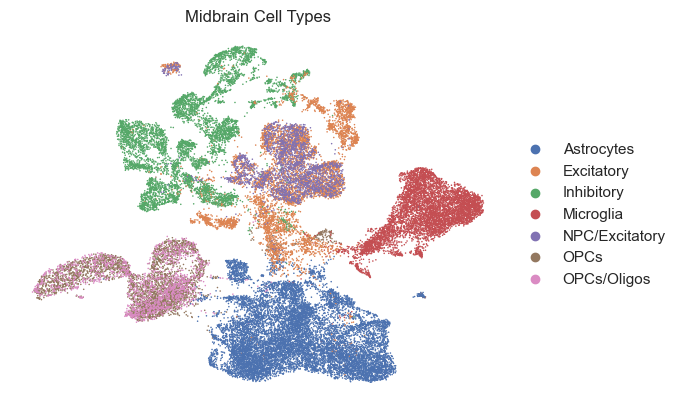

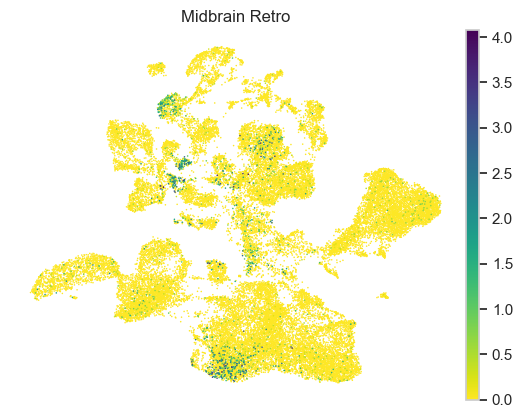

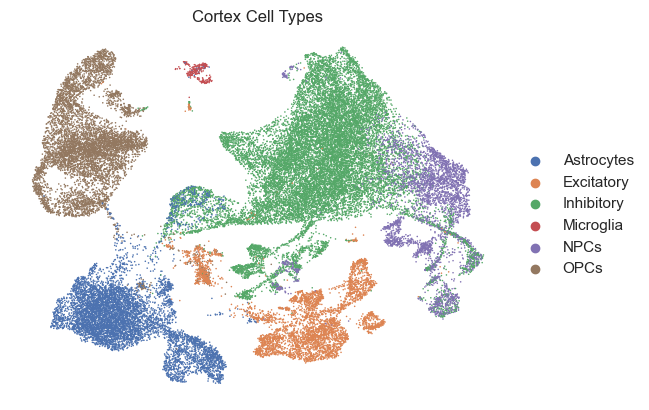

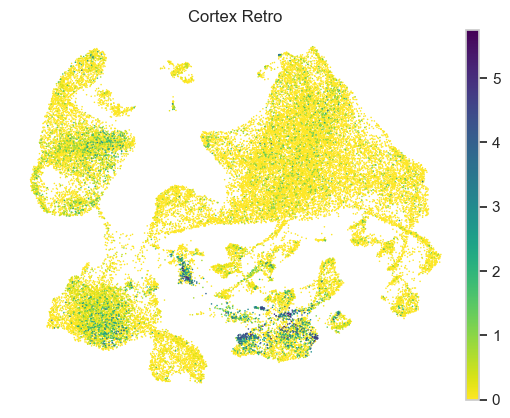

In [4]:
#sc.set_figure_params(figsize=(8, 6), dpi=300, frameon=False)
sc.pl.umap(midbrain, color=["cell_type"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Midbrain Cell Types")
sc.pl.umap(midbrain, color=["Retro"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Midbrain Retro", use_raw=False,cmap="viridis_r")
sc.pl.umap(cortex, color=["cell_type"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Cortex Cell Types")
sc.pl.umap(cortex, color=["Retro"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Cortex Retro", use_raw=False,cmap="viridis_r")

#### Midrain Features (All Replicates)
| Excitatory         |        | Inhibitory        |        |
|--------------------|--------|-------------------|--------|
| Gene               | Score  | Gene              | Score  |
| C1QL1              | 0.763  | C1QL3             | 0.5869 |
| TFAP2B             | 0.1755 | C1QL1             | 0.3773 |
| NDN                | 0.0305 | STMN1             | 0.0201 |
| C1QTNF4            | 0.0153 | EPHX4             | 0.0053 |
| STMN3              | 0.0101 | AY036118          | 0.0052 |
| PCSK1N             | 0.0032 | RSPO2             | 0.0034 |
| CHCHD10            | 0.0024 | PDE9A             | 0.0017 |


#### Cortex Features (All Replicates)
| Gene       | Score  |
|------------|--------|
| C1QL3      | 0.8052 |
| HSPA5      | 0.0300 |
| PIK3C2B    | 0.0295 |
| GM49450    | 0.0274 |
| SYNE2      | 0.0168 |
| GM19817    | 0.0128 |
| RAMP1      | 0.0122 |
| EGR1       | 0.0079 |
| MT1        | 0.0072 |
| GM37298    | 0.0066 |
| CHCHD10    | 0.0058 |
| GLIPR2     | 0.0057 |
| CDIN1      | 0.0056 |
| H2AZ1      | 0.0052 |
| 4930480K15RIK | 0.0051 |
| GM28379    | 0.0050 |
| JUNB       | 0.0043 |
| GM43668    | 0.0039 |
| GM42841    | 0.0038 |


### (2) TAP software flow chart

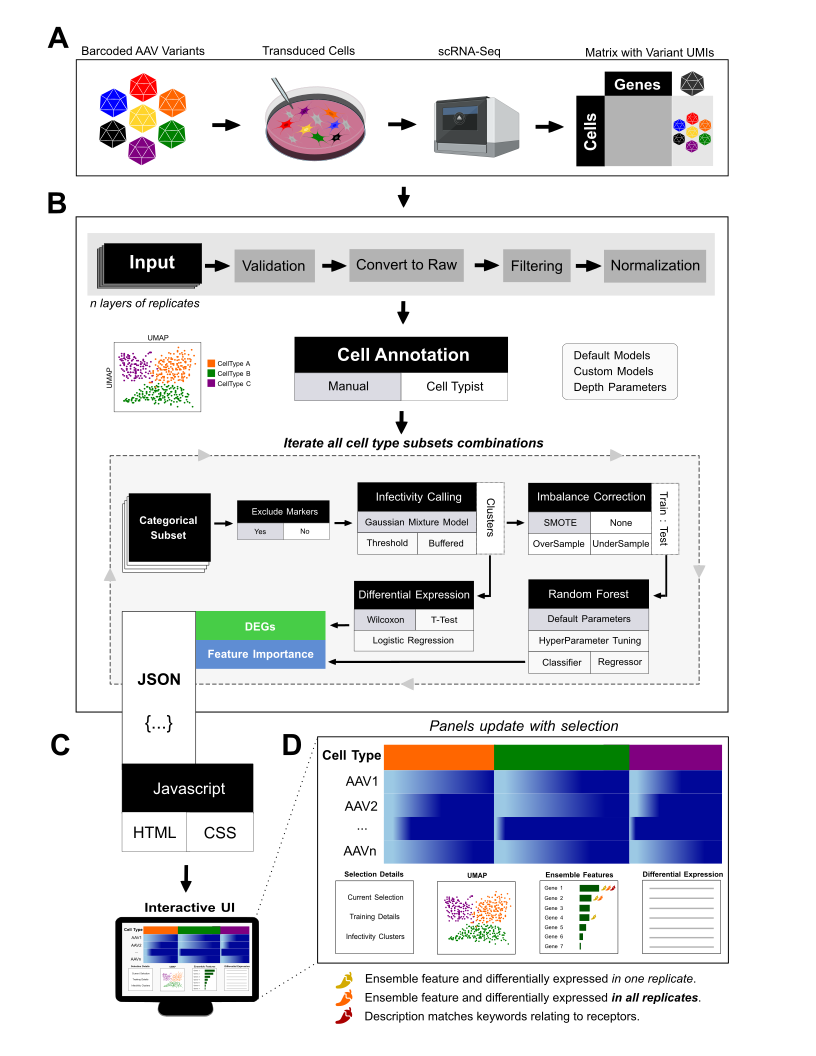

### (3) Capsid "competition" results (ie the three successive "retros").  M4 Retro, Retro_10, Retro_kash
<p>Just the important scores for each of the timepoints. Would include UMAP expression as well as C1QL3 importance scores for each retro.</p>

In [ ]:
m4_cortex_kash = sc.read_h5ad("/home/kenny/Documents/OHSU/Projects/molotAAV/Code/Analyses/M4/Cortex_1000_Kash_MT11/Data/Dialout/preprocessed.h5ad")

parameters = {
	"adataObject": m4_cortex_kash,
	"name": "M4 Cortex Kash",
	"genes": ["AAV1","AAV2","AAV5","AAV6","AAV7","AAV8","AAV9","Rh10","Retro_Kash","Retro","Retro_10","Anc80","SHH10"],
	"categories": ["cell_type"],
	"categoryNames": ["Cell Type"],
	"exclude" : ["Microglia","NPCs","OPCs","NPC/Excitatory"],
	"outputPath": "runs/",
	"outputName": "M4-Cortex-Kash.html",
	"excludeMarkers" : True,
	"clusterMethod": "threshold", 
	"clusterThreshold": 3,
	"clusterThresholdGreaterThanOrEqual": 3,
	"clusterThresholdLessThanOrEqual": 0,
	"balance": "smote",
	"minify": False,
	"replicate_mode": False,
	"removeOutliers": True,
}

results = t.TAP(**parameters)

#### TAP Results from above
<a href="https://staging.arpiarsaunderslab.org/storage/framework/filesystem/assets/d30d712d-3d25-4520-a1ee-30fde4cdcc53.html">https://staging.arpiarsaunderslab.org/storage/framework/filesystem/assets/d30d712d-3d25-4520-a1ee-30fde4cdcc53.html</a>

### M4 Cortex UMAPs

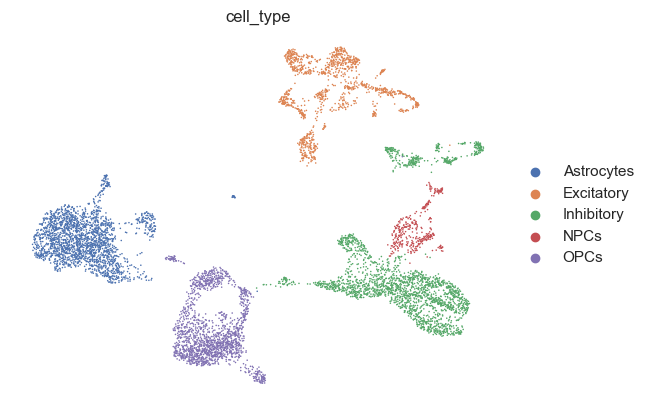

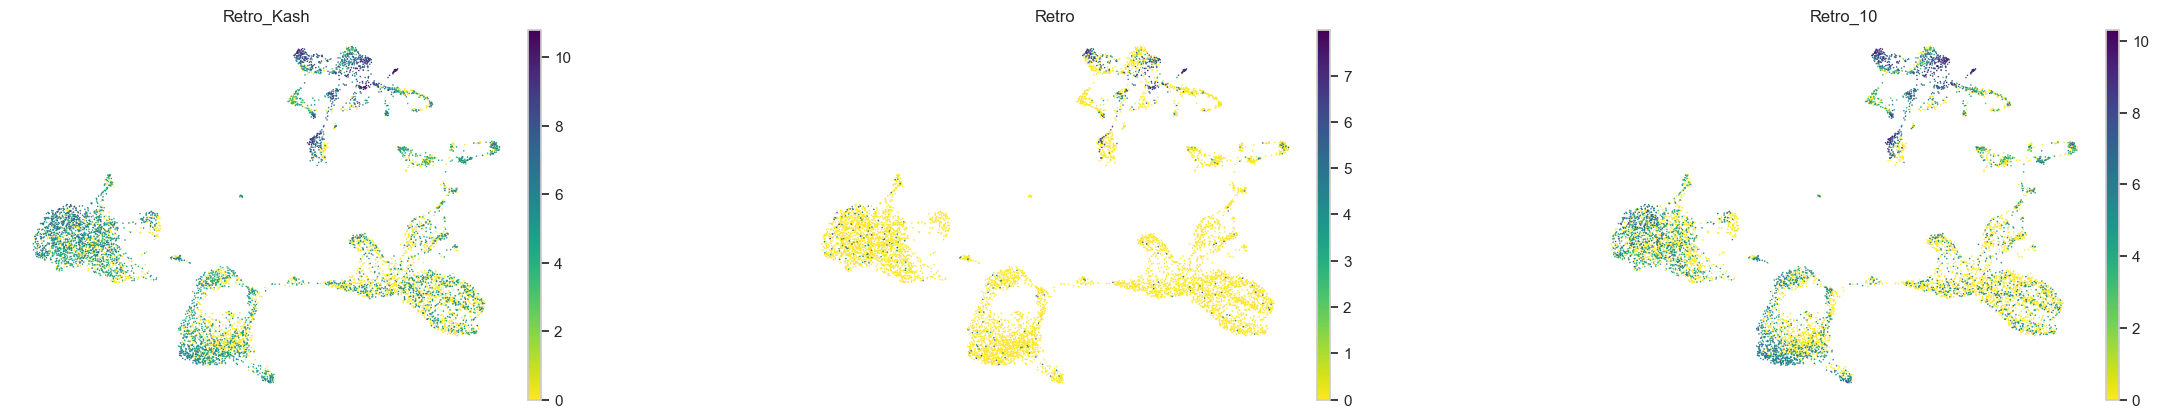

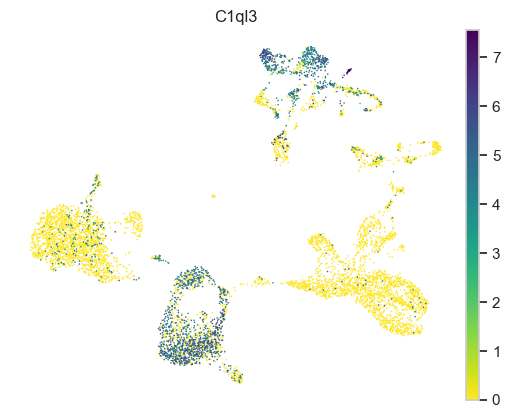

In [15]:
sc.pl.umap(m4_cortex_kash, color=["cell_type"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5, use_raw=False)
sc.pl.umap(m4_cortex_kash, color=["Retro_Kash","Retro","Retro_10"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5, use_raw=False, cmap="viridis_r")
sc.pl.umap(m4_cortex_kash, color=["C1ql3"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5, use_raw=False, cmap="viridis_r")

#### Importance scores of each retro timepoint
| retro_kash | score | retro | score | retro_10 | score |
|------------|-------|-------|-------|----------|-------|
| C1QL3      | 0.3977 | C1QL3      | 0.7162 | C1QL3      | 0.5282 |
| ENPP2      | 0.1563 | GM35188    | 0.1014 | CPNE6      | 0.1021 |
| CACNA2D3   | 0.1099 | EGR4       | 0.0452 | A2ML1      | 0.0763 |
| CPNE6      | 0.0668 | BDNF       | 0.0405 | SPARCL1    | 0.0495 |
| RASGRF1    | 0.0333 | SEMA3A     | 0.0223 | GFAP       | 0.0360 |
| IGFBP5     | 0.0295 | CCND2      | 0.0172 | RASGRF1    | 0.0316 |
| EPHA3      | 0.0269 | COX6A2     | 0.0124 | HOPX       | 0.0238 |
| NECTIN3    | 0.0247 | KHDRBS2    | 0.0078 | A830029E22RIK | 0.0178 |
| AW047730   | 0.0195 | GM26936    | 0.0076 | GUCY1A1    | 0.0175 |
| FOS        | 0.0124 | PCDH11X    | 0.0070 | RBP1       | 0.0138 |
| CNG4       | 0.0121 | RSPH1      | 0.0064 | CNG4       | 0.0137 |
| S100B      | 0.0108 | MPPED2     | 0.0057 | FBXO2      | 0.0132 |
| RPRM       | 0.0100 | 573052E02RIK | 0.0051 | MPPED2     | 0.0105 |
| PLPP3      | 0.0098 | EPHA3      | 0.0050 | CDH18      | 0.0091 |
| EGR4       | 0.0096 |            |        | RPRM       | 0.0074 |
| SPARCL1    | 0.0095 |            |        | BRINP1     | 0.0066 |
| CDH18      | 0.0094 |            |        | RESP18     | 0.0061 |
| HS3ST4     | 0.0077 |            |        | IGFBPL1    | 0.0055 |
| TPPP3      | 0.0072 |            |        | EPB41L2    | 0.0053 |
| CCSAP      | 0.0066 |            |        | PRDM8      | 0.0051 |
| GRM3       | 0.0065 |            |        | GNB4       | 0.0051 |
| DPP6       | 0.0056 |            |        |            |        |


#### (4) Lrfn5 UMAP and importance score association with SCH9

In [13]:
xinjin = sc.read_h5ad("../archive/data/GSE249416/GSE249416_AAV_ctxobj_2.Robj.h5ad")

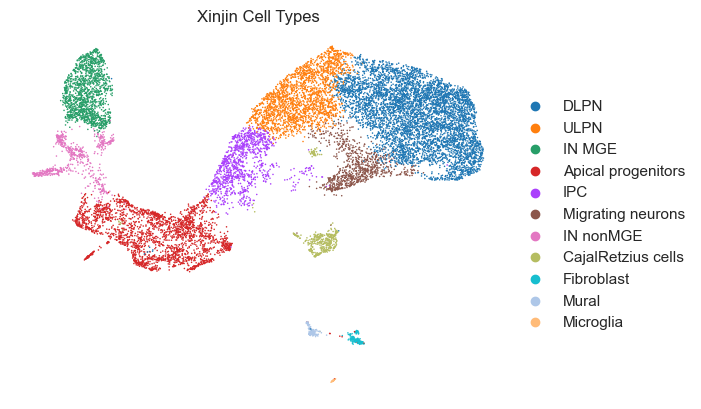

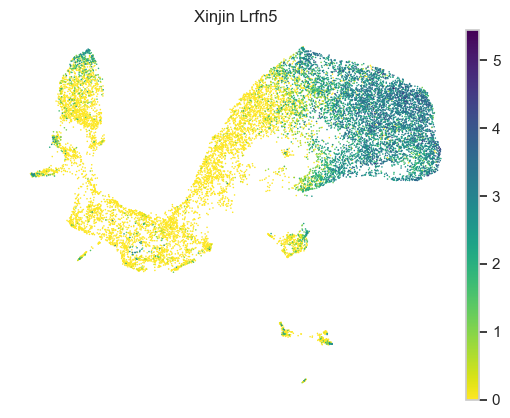

In [14]:
sc.pl.umap(xinjin, color=["xincelltype230416"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Xinjin Cell Types")
sc.pl.umap(xinjin, color=["Lrfn5"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Xinjin Lrfn5",cmap="viridis_r")

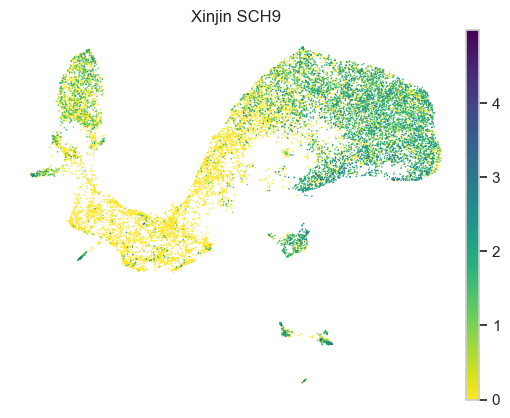

In [10]:
xinjin.obs["sch9"] = xinjin.obs["BC1a"] + xinjin.obs["BC1b"] + xinjin.obs["BC1c"]
xinjin.obs["sch9"] = np.log1p(xinjin.obs["sch9"])
sc.pl.umap(xinjin, color=["sch9"], frameon=False, wspace=0.4, hspace=0.4, ncols=4, size=5
	   , title="Xinjin SCH9",cmap="viridis_r")

| BC1 Genes | Score   | BC2 Genes | Score   | BC3 Genes | Score   |
|-----------|---------|-----------|---------|-----------|---------|
| LRFN5     | 0.7037  | NRG3      | 0.5977  | LRFN5     | 0.656   |
| HBB-BS    | 0.1161  | GRM8      | 0.1356  | TOX       | 0.1285  |
| NRG3      | 0.106   | RSPO3     | 0.0664  | TTR       | 0.0936  |
| CLSTN2    | 0.0307  | CLSTN2    | 0.0645  | SCHIP1    | 0.056   |
| DYNC1I1   | 0.0249  | HBB-BS    | 0.0267  | PLEK      | 0.0517  |
| HMGB2     | 0.0065  | ANP32B    | 0.022   | CLSTN2    | 0.0075  |
| GM16599   | 0.005   | HCN1      | 0.0187  | SEMA6A    | 0.0067  |
| SCHIP1    | 0.0045  | LRFN5     | 0.0145  |           |         |
| SLIT3     | 0.0024  | SST       | 0.0127  |           |         |
|           |         | KIRREL3   | 0.011   |           |         |
|           |         | SLC6A15   | 0.0108  |           |         |
